In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"]=".1"
os.environ["CUDA_VISIBLE_DEVICES"]="2"
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from balif import Balif

In [2]:
def plot_data(
    data_inlier,
    data_anomaly,
    x_lims: tuple[int, int] = (-5, 5),
    y_lims: tuple[int, int] = (-5, 5),
):
    plt.figure(figsize=(5, 5), dpi=80)
    plt.scatter(data_inlier[:, 0], data_inlier[:, 1], marker="o", c="grey", s=10, label="inlier")
    plt.scatter(
        data_anomaly[:, 0], data_anomaly[:, 1], marker="o", c="darksalmon", s=10, label="anomaly"
    )
    plt.legend()
    plt.xlim(*x_lims)
    plt.ylim(*y_lims)
    plt.grid()
    plt.show()

def plot_heatmap(
    model,
    x_lims: tuple[int, int] = (-5, 5),
    y_lims: tuple[int, int] = (-5, 5),
):
    X, Y = jnp.meshgrid(jnp.linspace(*x_lims, 100), jnp.linspace(*y_lims, 100))
    coord = jnp.stack([X.flatten(), Y.flatten()]).T
    scores = model.score_samples(coord, use_full_path=False)

    plt.figure(figsize=(6, 5), dpi=80)
    plt.imshow(
        scores.reshape(100, 100),
        extent=(-5, 5, -5, 5),
        cmap="YlOrRd",
        origin="lower",
        vmin=0,
        vmax=1,
    )
    plt.xticks([])
    plt.yticks([])
    plt.colorbar()

Double Blob

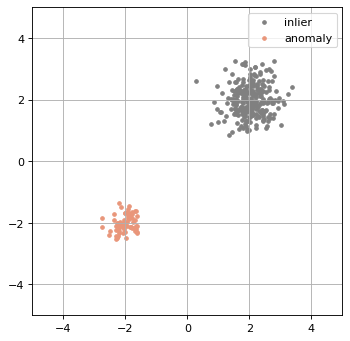

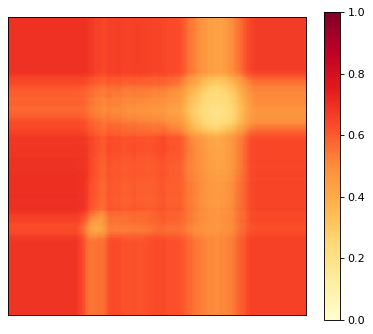

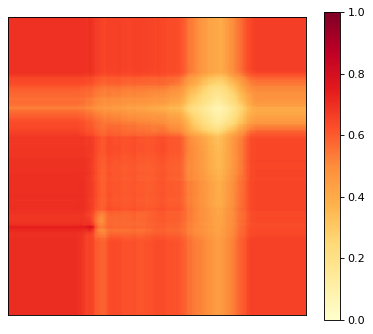

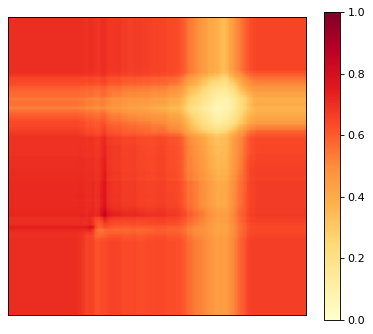

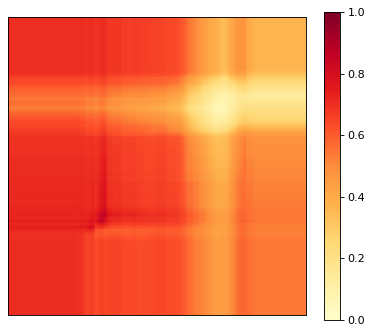

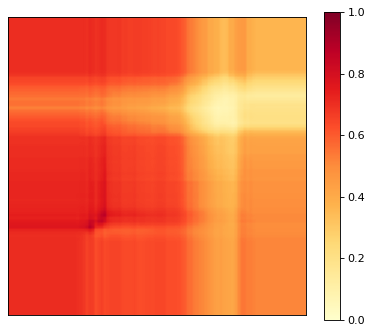

In [3]:
n_trees = 128
hyperplane_components = 1

rng_anom, rng_inlier, rng_forest = jax.random.split(jax.random.PRNGKey(42), 3)
data_anomaly = 0.3*jax.random.normal(rng_inlier, (64, 2)) - 2
data_inlier = 0.5*jax.random.normal(rng_anom, (256, 2)) + 2
data = jnp.concatenate([data_anomaly, data_inlier], axis=0)
forest = Balif.fit(rng_forest, data, n_trees, subsample_size, hyperplane_components)


N_labels = 5
plot_data(data_inlier, data_anomaly)
plot_heatmap(forest)
for i in range(N_labels-1):
    forest = forest.register(data_anomaly[i], is_anomaly=True)
    forest = forest.register(data_inlier[i], is_anomaly=False)
    plot_heatmap(forest)

Wave

Wave

In [4]:
n_trees = 128
hyperplane_components = 2

rng_data, rng_forest = jax.random.split(jax.random.PRNGKey(42), 2)
data = jax.random.normal(rng_inlier, (1024, 2))
data = data.at[:,0].mul(2)
data = data.at[:,1].set(0.1*data[:,1]+jnp.sin(3*data[:,0]))
print()
data_anomaly = data[jnp.where((1<data[:,0]) & (data[:,0]<2))]
data_inlier = data[jnp.where((data[:,0]<1) | (2<data[:,0]))]


data = jnp.concatenate([data_anomaly, data_inlier], axis=0)
forest = Balif.fit(rng_forest, data, n_trees, subsample_size, hyperplane_components)

N_labels = 5
plot(forest, data_inlier, data_anomaly)
for i in range(N_labels):
    forest = forest.register(data_anomaly[i], is_anomaly=True)
    forest = forest.register(data_inlier[i], is_anomaly=False)
    forest = forest.register(data_inlier[N_labels+i], is_anomaly=False)
    plot(forest, data_inlier, data_anomaly)